# **Import Statements**

In [1]:
root = "C:\\Users\\saman\\Documents\\Github\\Magnetic-Levitation\\"

import numpy as np
import matplotlib.pyplot as plt

from utils.boundary_disk import Cylinder



%load_ext autoreload
%autoreload 2
plt.style.use(root + "style.mplstyle")


# **Von Karman Rotating Disk Problem**

[3.69467069 0.98306554]
[10.9809575  -0.33273005]
[ 3.5732544  -0.99251957 10.9351499   0.25095186  0.4       ]


C:\Users\saman\AppData\Local\Temp\ipykernel_37456\1473439683.py:39: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(stupid_curve, s_sound, g_prime, p0 = (3.7, -0.98, 10.98, 0.33, 0.4))


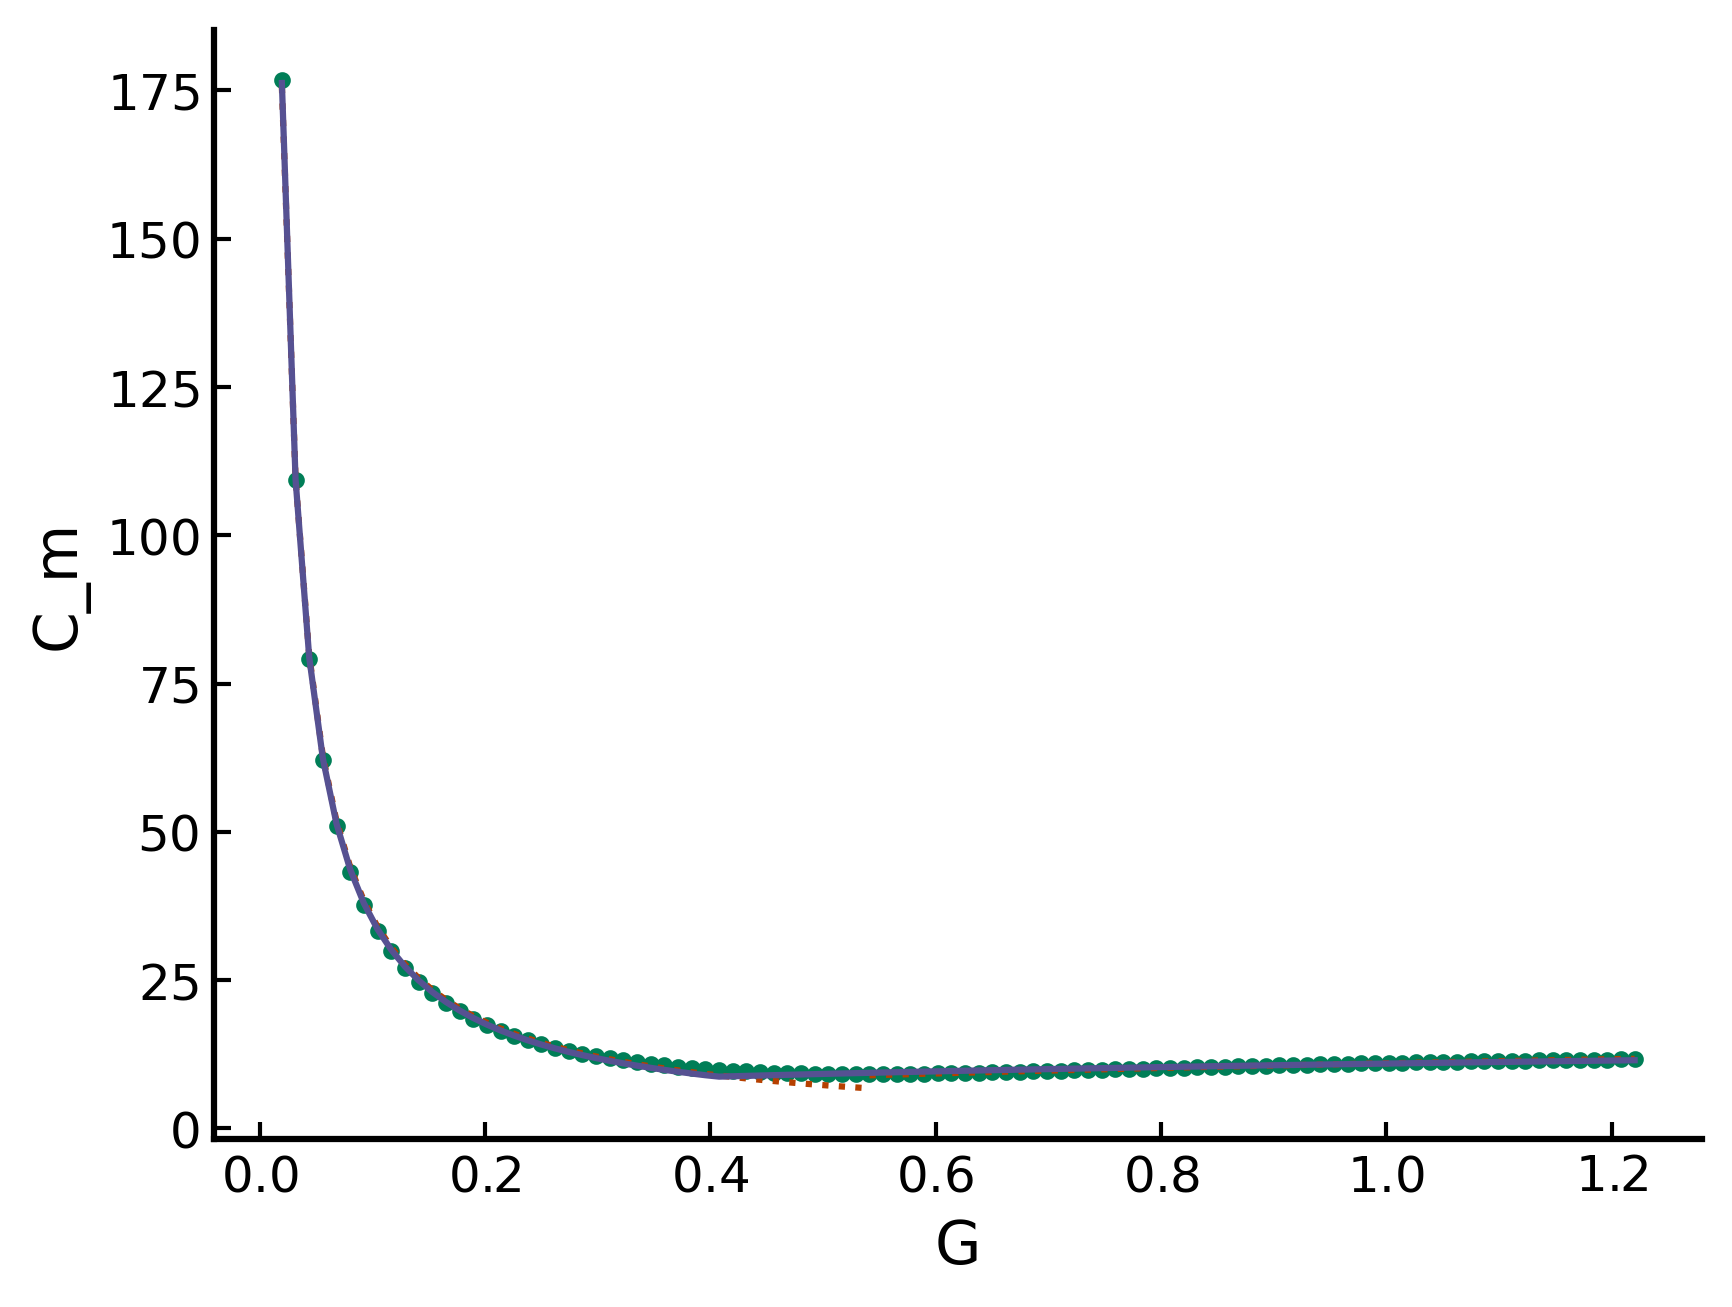

In [59]:
from scipy.optimize import curve_fit

cylinder = Cylinder( 
            b = 0.00254,  # radius in meters
            rho = 7500, # cylinder density in kg/m^3
            Omega = 1000, # angular velocity in rpm 
            rho_f = 1.226, # density of the fluid in kg/m^3
            mu = 1.795e-5, # viscosity of the fluid in pascal seconds
            elle = 0.0105, # total gap distance in meters
            L = 0.003175 # length of the cylinder in meters
        )

s_sound, g_prime = cylinder.disk_moment_coefficient(50e-6, 0.0031)
s_sound = s_sound/cylinder.b

R = cylinder.Omega*cylinder.b**2*cylinder.rho_f/cylinder.mu
g_prime = -np.pi*g_prime*R**0.5

idx = np.argmin(g_prime)

popt, _ = curve_fit(lambda x, a, b: a*x**(-b), s_sound[:idx], g_prime[:idx], p0 = (1, 1))
g_fit = popt[0]*s_sound**(-popt[1])
plt.plot(s_sound, g_prime, linestyle = '', marker = '.')
plt.plot(s_sound[:idx+1], g_fit[:idx+1], linestyle = ':')

print(popt)


popt, _ = curve_fit(lambda x, a, b: a*x**(-b), s_sound[idx:], g_prime[idx:], p0 = (1, 1))
g_fit = popt[0]*s_sound**(-popt[1])
plt.plot(s_sound[idx:], g_fit[idx:], linestyle = ':', c = 'C1')
print(popt)


def stupid_curve(x, a1, b1, a2, b2, s_crit):
    return np.piecewise(x, [x < s_crit, x >= s_crit], [lambda y: a1*y**b1, lambda y: a2*y**b2])
    

popt, _ = curve_fit(stupid_curve, s_sound, g_prime, p0 = (3.7, -0.98, 10.98, 0.33, 0.4))
print(popt)

plt.plot(s_sound, stupid_curve(s_sound, popt[0], popt[1], popt[2], popt[3], popt[4]))


#plt.axvline(s_sound[idx], c = 'black', linestyle = '--')
plt.ylabel("C_m")
plt.xlabel("G")
plt.show()

# **Normalized Dissipation v. Normalized Gap Distance**

In [61]:
cylinder = Cylinder( 
            b = 0.00254,  # radius in meters
            rho = 7500, # cylinder density in kg/m^3
            Omega = 1000, # angular velocity in rpm 
            rho_f = 1.226, # density of the fluid in kg/m^3
            mu = 1.795e-5, # viscosity of the fluid in pascal seconds
            elle = 0.0105, # total gap distance in meters
            L = 0.003175 # length of the cylinder in meters
        )

gap_exp = np.asarray([0.00027, 0.00075, 0.00253]) #in meters
tau_exp = np.asarray([85, 100, 110]) #in seconds

#Linear Fit
s_array_lin, dissipation_lin, dissipation_fit_lin = cylinder.linear_damping(
    gap = gap_exp, #in meters
    tau = tau_exp, # in seconds
    start = 1e-6, #in meters
    stop = 0.0031 # in meters
)

#Enclosed Rotor-Stator Fit
s_array_ers, dissipation_ers, s_crit_ers = cylinder.enclosed_rotor_stator(
    gap = gap_exp, #in meters
    tau = tau_exp, # in seconds
    start = 60e-6, #in meters
    stop = 0.0031 # in meters
)

#Enclosed Rotor-Stator Fit
s_array_ors, dissipation_ors = cylinder.open_rotor_stator(
    gap = gap_exp, #in meters
    tau = tau_exp, # in seconds
    start = 60e-6, #in meters
    stop = 0.0031 # in meters
)

#COMSOL Simulation
gap_COMSOL = 2.075  + np.asarray([-2.05, -1.95, -1.85, -1.75, -1.55, -1.45, -1.35, -1.25, -1.15, -1.05, -0.9499999999999997, -0.8499999999999996, -0.7499999999999998,
                                    -0.6499999999999997, -0.5499999999999998, -0.4499999999999997, -2.05, -2.04, -2.03, -2.02, -2.01, -2, -1.8, 1, 0.5, 0]) # in mm
gap_COMSOL = gap_COMSOL/1000 #convert from mm to meters
dissipation_COMSOL = np.asarray([7.276218039755276e-08, 3.54147777132402e-08, 3.319989813145014e-08, 2.999256618224352e-08, 2.397974446357202e-08, 
                                    2.315700597492343e-08, 2.161300607312653e-08, 2.059531916586093e-08, 1.818476156508958e-08, 1.805479547545832e-08,
                                    1.770094325751496e-08, 1.810964892360439e-08, 1.738181837805184e-08, 1.713697045790447e-08, 1.696140911262177e-08,
                                    1.69594542751747e-08, 7.276218039755276e-08, 6.27325979686784e-08, 5.517541944117902e-08, 5.178201911733897e-08, 
                                    4.28650162841852e-08, 4.237478948935986e-08, 3.154069141653727e-08, 1.639943102219439e-08, 1.625977604031675e-08, 1.660765723313549e-08]) #in Watts/m^2

'''
Plotting
'''

# Linear Fit
plt.plot(s_array_lin/cylinder.b, dissipation_fit_lin/np.min(dissipation_fit_lin), linestyle = '--', c = 'C0')
plt.plot(gap_exp/cylinder.b, dissipation_lin/np.min(dissipation_lin), linestyle = '', marker = 'o', label = 'Analytical linear damping \nfrom experiment', c = 'C0')

#Enclosed Rotor-Stator
plt.plot(s_array_ers/cylinder.b, dissipation_ers/np.min(dissipation_ers), linestyle = '--', label = 'Enclosed rotor-stator theory', c = 'C2')
plt.axvline(x = s_crit_ers/cylinder.b, c = 'black', linestyle = '--', label = r'$s_\mathrm{crit, enclosed}$')

#Open Rotor-Stator
plt.plot(s_array_ors/cylinder.b, dissipation_ors/np.min(dissipation_ors), linestyle = '--', label = 'Open rotor-stator theory', c = 'C3')

# COMSOL
plt.plot(gap_COMSOL/cylinder.b, dissipation_COMSOL/np.min(dissipation_COMSOL), linestyle = '', marker = '*', label = 'COMSOL simulation', c = 'C1')

plt.xlabel(r"gap ratio $\left[\frac{s}{b} \right]$", weight = 'heavy', fontsize = "xx-large")
plt.ylabel(r"Normalized dissipation $\left[\frac{\mathcal{D}}{\mathcal{D}_0} \right]$", weight = 'heavy', fontsize = "xx-large")
plt.legend(prop={'size': 12})
plt.show()

AttributeError: 'Cylinder' object has no attribute 'open_rotor_stator'

---